### Phần 1 - EDA

**Phiên bản Spark/HDFS:** đọc dữ liệu từ HDFS bằng PySpark, giữ các biểu đồ EDA bằng cách chuyển các bảng tổng hợp nhỏ hoặc mẫu dữ liệu sang pandas để vẽ bằng matplotlib/seaborn.


In [1]:
# Install & Import
# Nếu chạy trong môi trường đã cài sẵn thư viện, có thể comment dòng pip để tránh cài lại mỗi lần.
# !pip install -q pandas numpy matplotlib seaborn scipy pyspark

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import time

from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark import StorageLevel
from pyspark.sql.functions import (
    col, count, sum as spark_sum, avg, when, isnan, trim,
    to_timestamp, to_date, hour, date_format, corr
)

warnings.filterwarnings("ignore")

# Config
TARGET_COL = "Is Fraudulent"
DATE_COL = "Transaction Date"
PALETTE = {0: "#4C9BE8", 1: "#E84C4C"}
PLOT_SAMPLE_SIZE = 100_000   # dùng cho KDE/boxplot để không kéo toàn bộ dữ liệu Spark về RAM
plt.style.use("seaborn-v0_8-whitegrid")

spark = SparkSession.builder \
    .appName("FraudDetection_EDA_HDFS_Spark") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

schema = StructType([
    StructField("Transaction ID",       StringType(),  True),
    StructField("Customer ID",          StringType(),  True),
    StructField("Transaction Amount",   DoubleType(),  True),
    StructField("Transaction Date",     StringType(),  True),
    StructField("Payment Method",       StringType(),  True),
    StructField("Product Category",     StringType(),  True),
    StructField("Quantity",             IntegerType(), True),
    StructField("Customer Age",         IntegerType(), True),
    StructField("Customer Location",    StringType(),  True),
    StructField("Device Used",          StringType(),  True),
    StructField("IP Address",           StringType(),  True),
    StructField("Shipping Address",     StringType(),  True),
    StructField("Billing Address",      StringType(),  True),
    StructField("Is Fraudulent",        IntegerType(), True),
    StructField("Account Age Days",     IntegerType(), True),
    StructField("Transaction Hour",     IntegerType(), True),
])

print("Done")


Done


In [2]:
# Load Data from HDFS by Spark
df = spark.read.csv(
    "hdfs://localhost:9000/final/fraud_300k_raw_temporal.csv",
    header=True,
    schema=schema,
    multiLine=True,
    escape='"'
)

# Chuyển cột ngày sang timestamp để dùng cho phân tích temporal.
# Nếu format ngày trong file khác chuẩn Spark, cần thêm format vào to_timestamp(col(DATE_COL), "...")
df = df.withColumn(DATE_COL, to_timestamp(col(DATE_COL)))

# Cache vì notebook EDA sẽ gọi count/groupBy nhiều lần
df = df.persist(StorageLevel.MEMORY_AND_DISK)
total_rows = df.count()

print(f"Loaded: {total_rows:,} rows × {len(df.columns)} columns")
df.show(3, truncate=False)


Loaded: 300,000 rows × 16 columns
+------------------------------------+------------------------------------+------------------+-------------------+--------------+----------------+--------+------------+-----------------+-----------+---------------+------------------------------------------------------+------------------------------------------------------+-------------+----------------+----------------+
|Transaction ID                      |Customer ID                         |Transaction Amount|Transaction Date   |Payment Method|Product Category|Quantity|Customer Age|Customer Location|Device Used|IP Address     |Shipping Address                                      |Billing Address                                       |Is Fraudulent|Account Age Days|Transaction Hour|
+------------------------------------+------------------------------------+------------------+-------------------+--------------+----------------+--------+------------+-----------------+-----------+---------------+------

In [3]:
# Basic Overview for PySpark DataFrame

print("--- Shape ---")
print(f"  Rows: {total_rows:,}  |  Columns: {len(df.columns)}")

print("\n--- Data Types ---")
for col_name, dtype in df.dtypes:
    print(f"{col_name}: {dtype}")

print("\n--- Schema ---")
df.printSchema()

print("\n--- First 5 Rows ---")
df.show(5, truncate=False)


--- Shape ---
  Rows: 300,000  |  Columns: 16

--- Data Types ---
Transaction ID: string
Customer ID: string
Transaction Amount: double
Transaction Date: timestamp
Payment Method: string
Product Category: string
Quantity: int
Customer Age: int
Customer Location: string
Device Used: string
IP Address: string
Shipping Address: string
Billing Address: string
Is Fraudulent: int
Account Age Days: int
Transaction Hour: int

--- Schema ---
root
 |-- Transaction ID: string (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Transaction Amount: double (nullable = true)
 |-- Transaction Date: timestamp (nullable = true)
 |-- Payment Method: string (nullable = true)
 |-- Product Category: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- Customer Age: integer (nullable = true)
 |-- Customer Location: string (nullable = true)
 |-- Device Used: string (nullable = true)
 |-- IP Address: string (nullable = true)
 |-- Shipping Address: string (nullable = true)
 |-- B

In [4]:
# Data Quality Check
print("MISSING VALUES")

missing_row = df.select([
    spark_sum(
        when(col(c).isNull() | isnan(col(c)), 1).otherwise(0)
    ).alias(c)
    if dtype in ["double", "float"]
    else
    spark_sum(
        when(col(c).isNull(), 1).otherwise(0)
    ).alias(c)
    for c, dtype in df.dtypes
]).collect()[0].asDict()

missing = pd.Series(missing_row)
missing_pct = (missing / total_rows * 100).round(2)
quality_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
quality_df = quality_df[quality_df["Missing Count"] > 0].sort_values("Missing %", ascending=False)

if quality_df.empty:
    print(" Không có missing values!")
else:
    display(quality_df)


print("DUPLICATES")

duplicate_all = total_rows - df.dropDuplicates().count()
duplicate_transaction_id = total_rows - df.dropDuplicates(["Transaction ID"]).count()
duplicate_customer_timestamp = total_rows - df.dropDuplicates(["Customer ID", DATE_COL]).count()

print(f"  Duplicate rows (toàn bộ):           {duplicate_all:,}")
print(f"  Duplicate Transaction IDs:           {duplicate_transaction_id:,}")
print(f"  Same Customer + same timestamp:      {duplicate_customer_timestamp:,}")


MISSING VALUES
 Không có missing values!
DUPLICATES
  Duplicate rows (toàn bộ):           0
  Duplicate Transaction IDs:           0
  Same Customer + same timestamp:      0


  Non-Fraud (0):  285,006  (95.00%)
  Fraud     (1):   14,994  (5.00%)
  Imbalance ratio: 1 : 19.0

HIGH imbalance (<5%) — cần class_weight


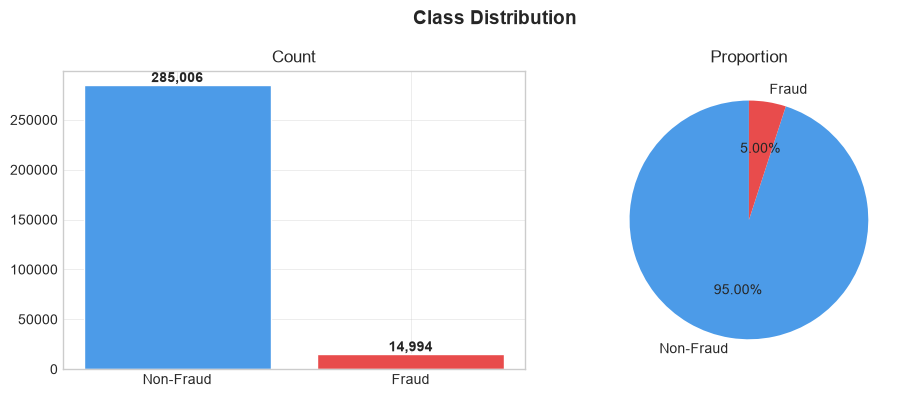

In [5]:
# Class Distribution
class_counts = (
    df.groupBy(TARGET_COL)
      .count()
      .orderBy(TARGET_COL)
      .toPandas()
)

counts = class_counts.set_index(TARGET_COL)["count"].reindex([0, 1], fill_value=0)
pct    = counts / counts.sum() * 100

print(f"  Non-Fraud (0): {counts[0]:>8,}  ({pct[0]:.2f}%)")
print(f"  Fraud     (1): {counts[1]:>8,}  ({pct[1]:.2f}%)")

if counts[1] > 0:
    print(f"  Imbalance ratio: 1 : {counts[0]/counts[1]:.1f}")
else:
    print("  Imbalance ratio: không tính được vì không có Fraud class")

if pct[1] < 1:
    print("\nSEVERE imbalance (<1%) — cân nhắc anomaly detection")
elif pct[1] < 5:
    print("\nHIGH imbalance (<5%) — cần class_weight")
else:
    print("\nMODERATE imbalance — class_weight thường đủ")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Class Distribution", fontsize=14, fontweight="bold")

axes[0].bar(["Non-Fraud", "Fraud"], counts.values,
            color=[PALETTE[0], PALETTE[1]], edgecolor="white")
axes[0].set_title("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + max(counts.max() * 0.01, 10), f"{v:,}", ha="center", fontweight="bold")

axes[1].pie(counts.values, labels=["Non-Fraud", "Fraud"],
            colors=[PALETTE[0], PALETTE[1]],
            autopct="%1.2f%%", startangle=90)
axes[1].set_title("Proportion")

plt.tight_layout()
plt.show()


Point-Biserial Correlation & Mann-Whitney U Test vs. Fraud Label

Số dòng dùng cho kiểm định và biểu đồ: 300,000


,Mean (Non-Fraud),Mean (Fraud),Correlation,p-value,Significant?
Feature,,,,,
Transaction Amount,209.48,549.90,0.2739,0.0000,Yes
Quantity,3.00,3.00,0.0003,0.8672,No
Customer Age,34.50,34.40,-0.0023,0.2982,No
Account Age Days,183.49,118.04,-0.1334,0.0000,Yes
Transaction Hour,11.48,7.89,-0.1124,0.0000,Yes


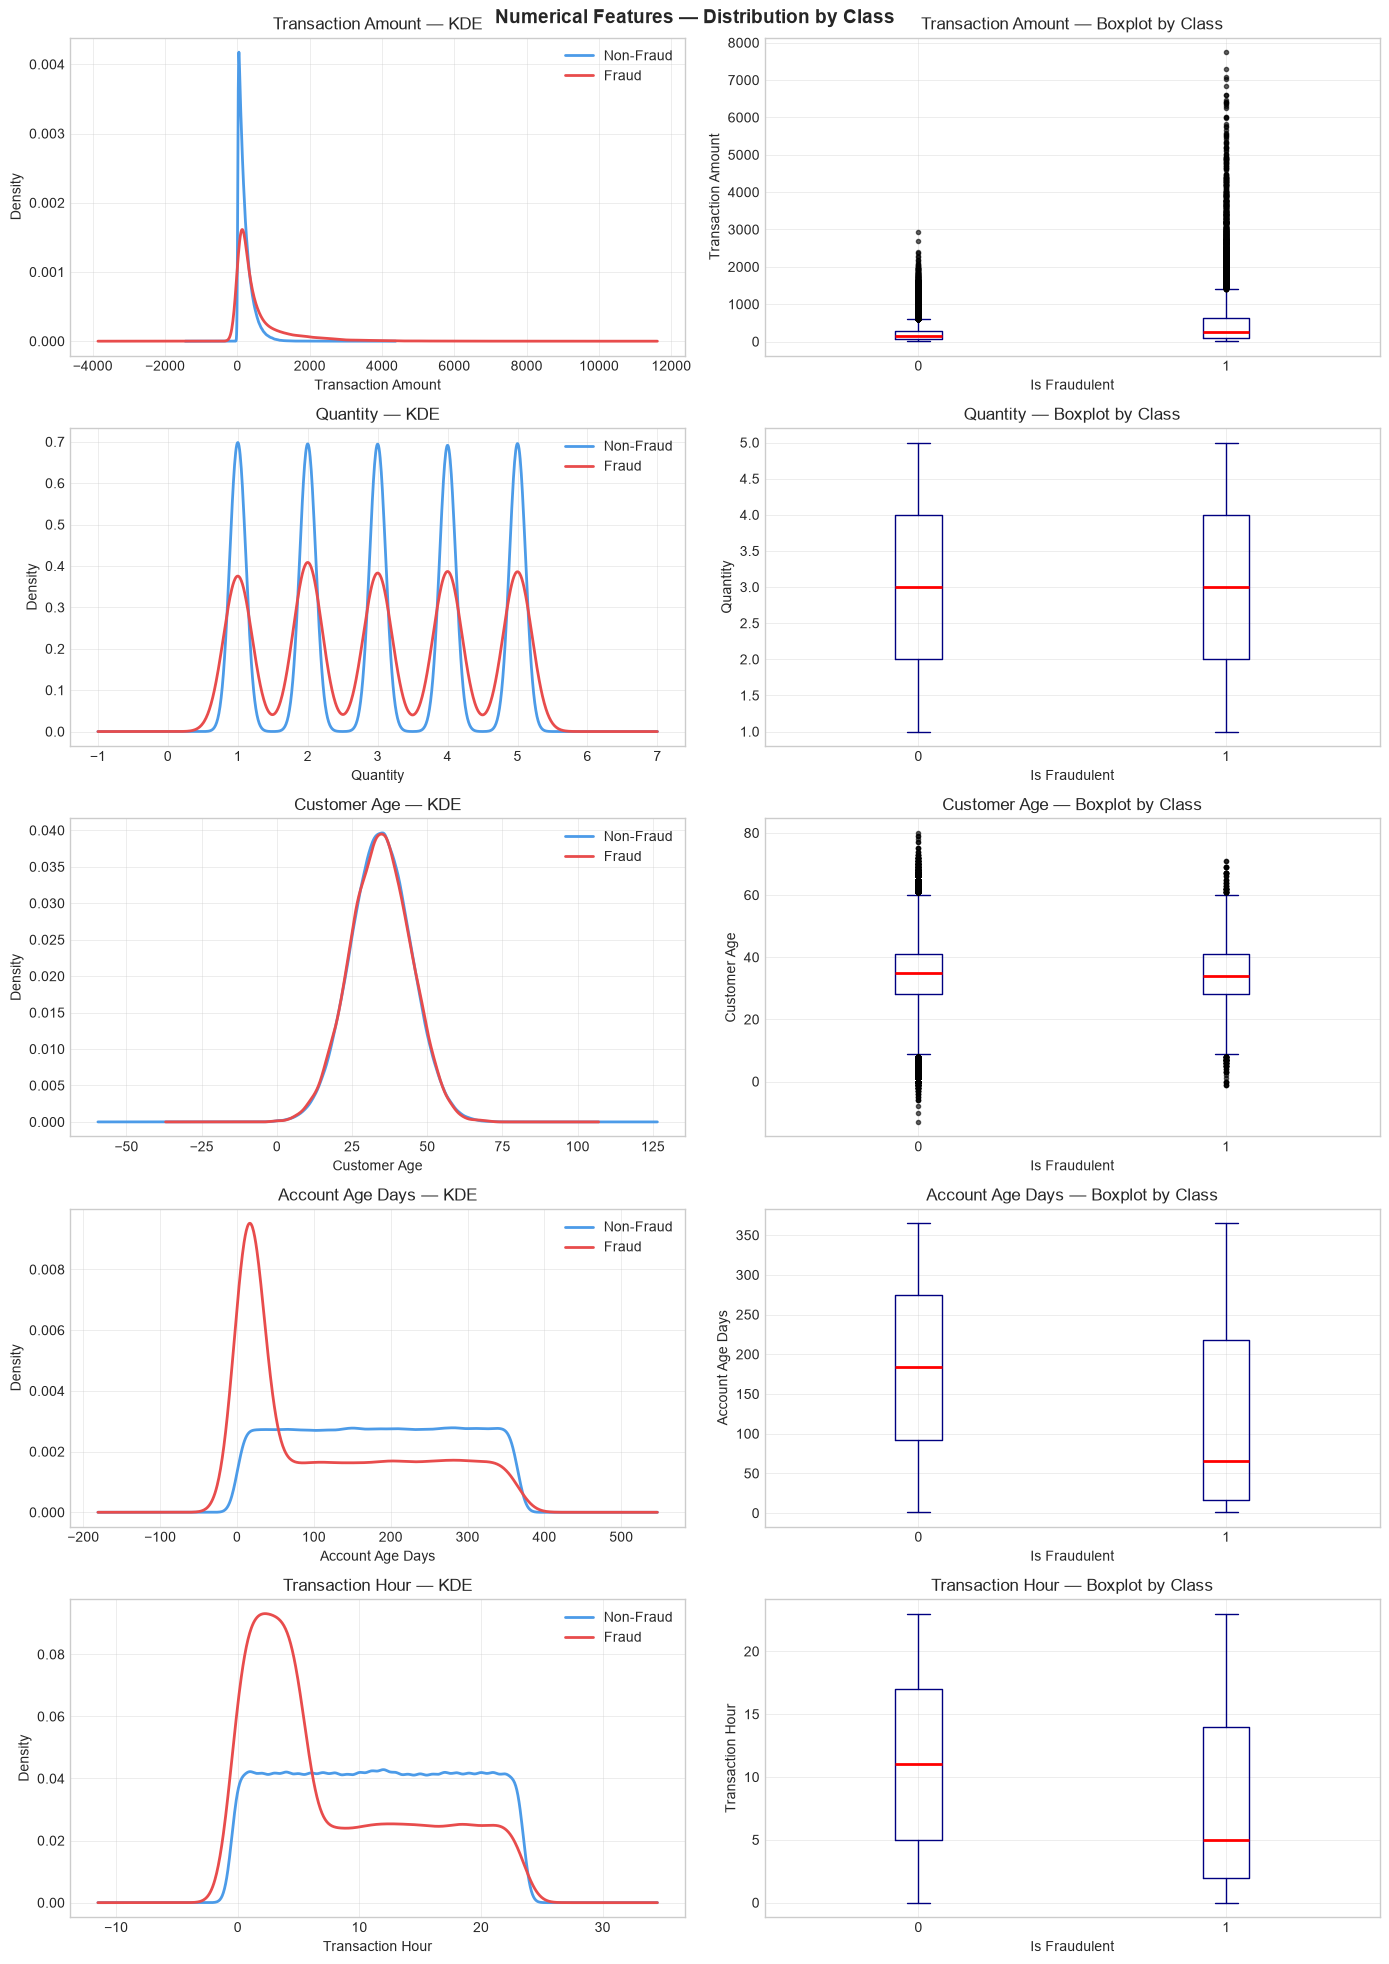

In [10]:
# Numerical Features — Distribution & Significance Test
from pyspark.sql.functions import col, avg, corr
from scipy import stats
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

num_cols = [c for c in ["Transaction Amount", "Quantity", "Customer Age",
                        "Account Age Days", "Transaction Hour"] if c in df.columns]

print("Point-Biserial Correlation & Mann-Whitney U Test vs. Fraud Label\n")
results = []

# Lấy ĐỦ dữ liệu từ Spark để phục vụ kiểm định và vẽ KDE/boxplot
# Lưu ý: phần này chuyển dữ liệu Spark về pandas để matplotlib/scipy xử lý.
# Với file khoảng 300k dòng thì thường ổn; nếu dữ liệu vài triệu dòng thì có thể rất nặng RAM.
df_num = df.select(
    [col(TARGET_COL).cast("int").alias(TARGET_COL)] +
    [col(c).cast("double").alias(c) for c in num_cols]
).dropna(subset=[TARGET_COL])

total_plot_rows = df_num.count()
print(f"Số dòng dùng cho kiểm định và biểu đồ: {total_plot_rows:,}")

plot_pdf = df_num.toPandas()

for c in num_cols:
    mean_row = (
        df_num.groupBy(TARGET_COL)
              .agg(avg(col(c)).alias("mean_value"))
              .toPandas()
              .set_index(TARGET_COL)["mean_value"]
              .reindex([0, 1])
    )

    g0 = plot_pdf.loc[plot_pdf[TARGET_COL] == 0, c].dropna()
    g1 = plot_pdf.loc[plot_pdf[TARGET_COL] == 1, c].dropna()

    if len(g0) > 0 and len(g1) > 0:
        _, p_mw = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    else:
        p_mw = np.nan

    corr_row = (
        df_num.select(
            corr(
                col(TARGET_COL).cast("double"),
                col(c).cast("double")
            ).alias("corr")
        ).collect()[0]
    )

    corr_value = corr_row["corr"]

    results.append({
        "Feature": c,
        "Mean (Non-Fraud)": round(mean_row.loc[0], 2) if pd.notna(mean_row.loc[0]) else np.nan,
        "Mean (Fraud)": round(mean_row.loc[1], 2) if pd.notna(mean_row.loc[1]) else np.nan,
        "Correlation": round(corr_value, 4) if corr_value is not None else np.nan,
        "p-value": round(p_mw, 4) if pd.notna(p_mw) else np.nan,
        "Significant?": "Yes" if pd.notna(p_mw) and p_mw < 0.05 else "No"
    })

display(pd.DataFrame(results).set_index("Feature"))


# KDE + Boxplot
fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 4 * len(num_cols)))

if len(num_cols) == 1:
    axes = np.array([axes])

fig.suptitle("Numerical Features — Distribution by Class", fontsize=14, fontweight="bold")

for i, c in enumerate(num_cols):
    # KDE
    for label, color in PALETTE.items():
        subset = plot_pdf.loc[plot_pdf[TARGET_COL] == label, c].dropna()

        if len(subset) > 1:
            subset.plot.kde(
                ax=axes[i, 0],
                label=f"{'Fraud' if label else 'Non-Fraud'}",
                color=color,
                linewidth=2
            )

    axes[i, 0].set_title(f"{c} — KDE")
    axes[i, 0].set_xlabel(c)
    axes[i, 0].legend()

    # Boxplot có hiển thị outliers bằng chấm đen
    plot_pdf.boxplot(
        column=c,
        by=TARGET_COL,
        ax=axes[i, 1],
        showfliers=True,
        whis=1.5,
        boxprops=dict(color="navy"),
        medianprops=dict(color="red", linewidth=2),
        whiskerprops=dict(color="navy"),
        capprops=dict(color="navy"),
        flierprops=dict(
            marker="o",
            markerfacecolor="black",
            markeredgecolor="black",
            markersize=3,
            linestyle="none",
            alpha=0.6
        )
    )

    axes[i, 1].set_title(f"{c} — Boxplot by Class")
    axes[i, 1].set_xlabel("Is Fraudulent")
    axes[i, 1].set_ylabel(c)

# Xóa suptitle mặc định do pandas boxplot(by=...) tự thêm
plt.suptitle("")
fig.suptitle("Numerical Features — Distribution by Class", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()


Payment Method:


,Payment Method,Fraud Count,Total,Fraud %
0,PayPal,3791,74935,5.06
1,debit card,3764,75053,5.02
2,bank transfer,3749,74912,5.00
3,credit card,3690,75100,4.91



Product Category:


,Product Category,Fraud Count,Total,Fraud %
0,health & beauty,3121,60359,5.17
1,clothing,3076,59867,5.14
2,home & garden,2982,59862,4.98
3,toys & games,2916,59798,4.88
4,electronics,2899,60114,4.82



Device Used:


,Device Used,Fraud Count,Total,Fraud %
0,mobile,5038,100094,5.03
1,desktop,4988,99702,5.00
2,tablet,4968,100204,4.96


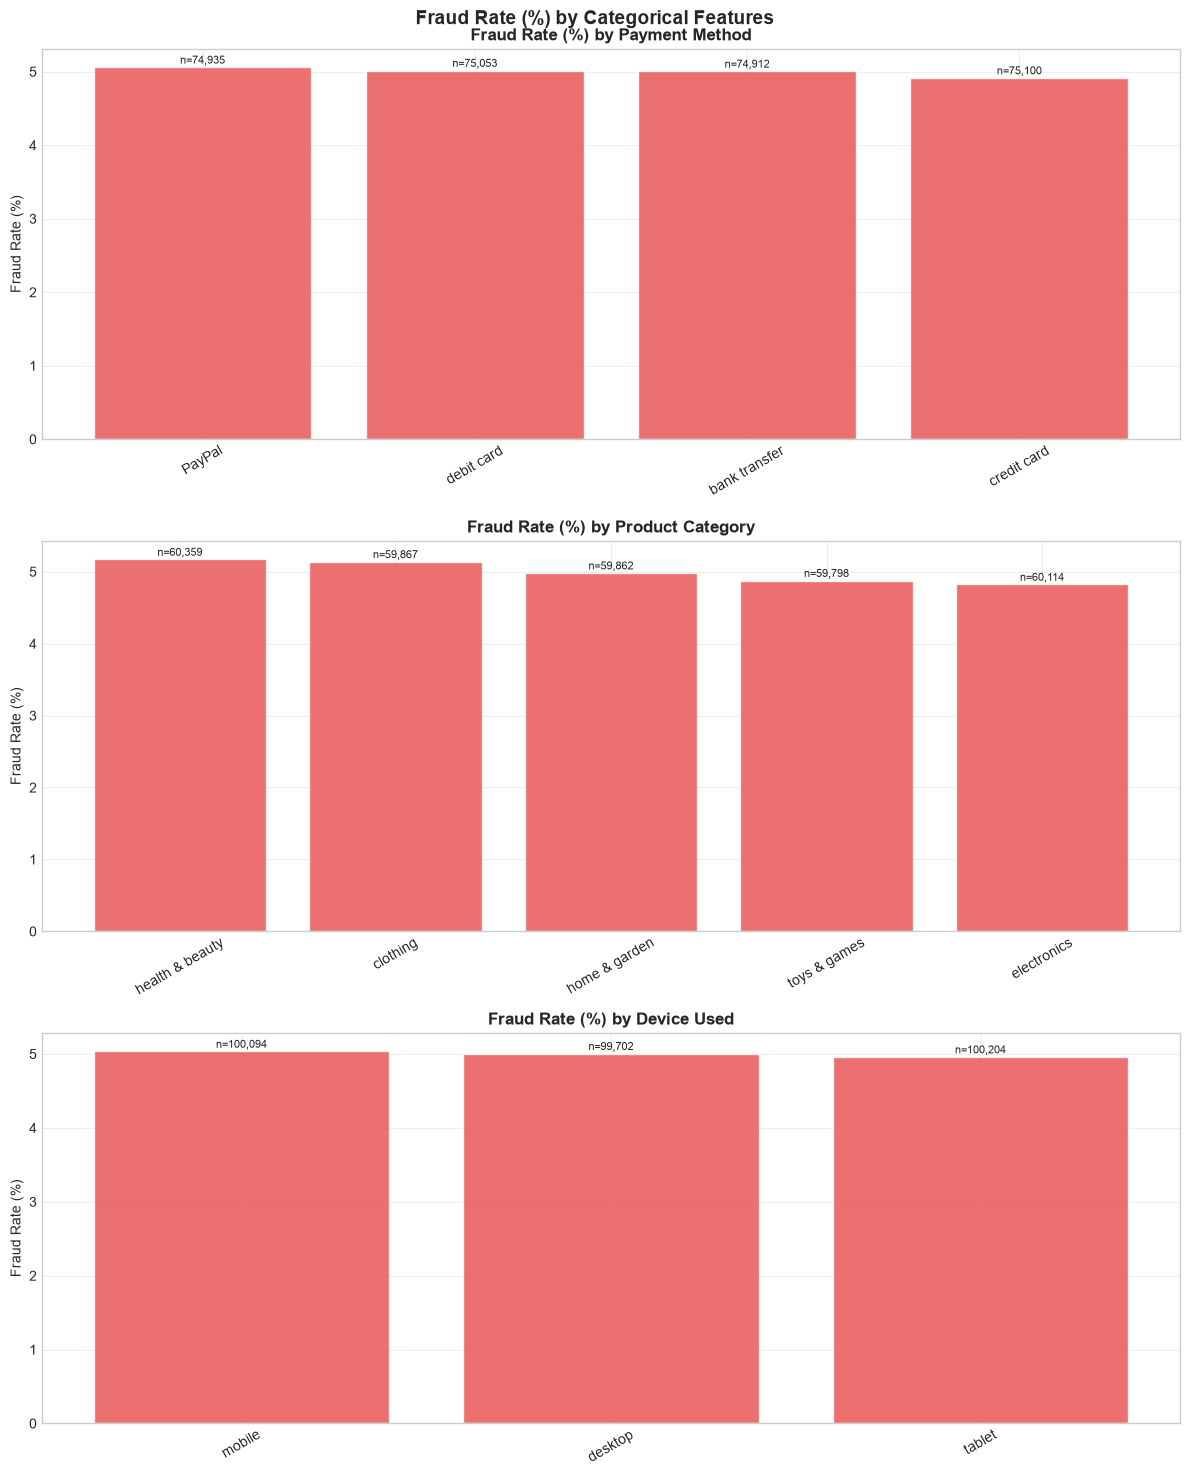

In [7]:
# Categorical Features — Fraud Rate
cat_cols = [c for c in ["Payment Method", "Product Category", "Device Used"] if c in df.columns]

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(12, 5 * len(cat_cols)))
if len(cat_cols) == 1:
    axes = [axes]
fig.suptitle("Fraud Rate (%) by Categorical Features", fontsize=14, fontweight="bold")

for i, c in enumerate(cat_cols):
    fraud_rate = (
        df.groupBy(c)
          .agg(
              spark_sum(col(TARGET_COL)).alias("Fraud Count"),
              count("*").alias("Total")
          )
          .withColumn("Fraud %", col("Fraud Count") / col("Total") * 100)
          .orderBy(col("Fraud %").desc())
          .toPandas()
    )

    print(f"\n{c}:")
    display(fraud_rate.round(2))

    bars = axes[i].bar(fraud_rate[c].astype(str), fraud_rate["Fraud %"],
                       color="#E84C4C", alpha=0.8, edgecolor="white")
    axes[i].set_title(f"Fraud Rate (%) by {c}", fontweight="bold")
    axes[i].set_ylabel("Fraud Rate (%)")
    axes[i].tick_params(axis="x", rotation=30)

    for bar, (_, row) in zip(bars, fraud_rate.iterrows()):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.05,
                     f"n={int(row['Total']):,}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()


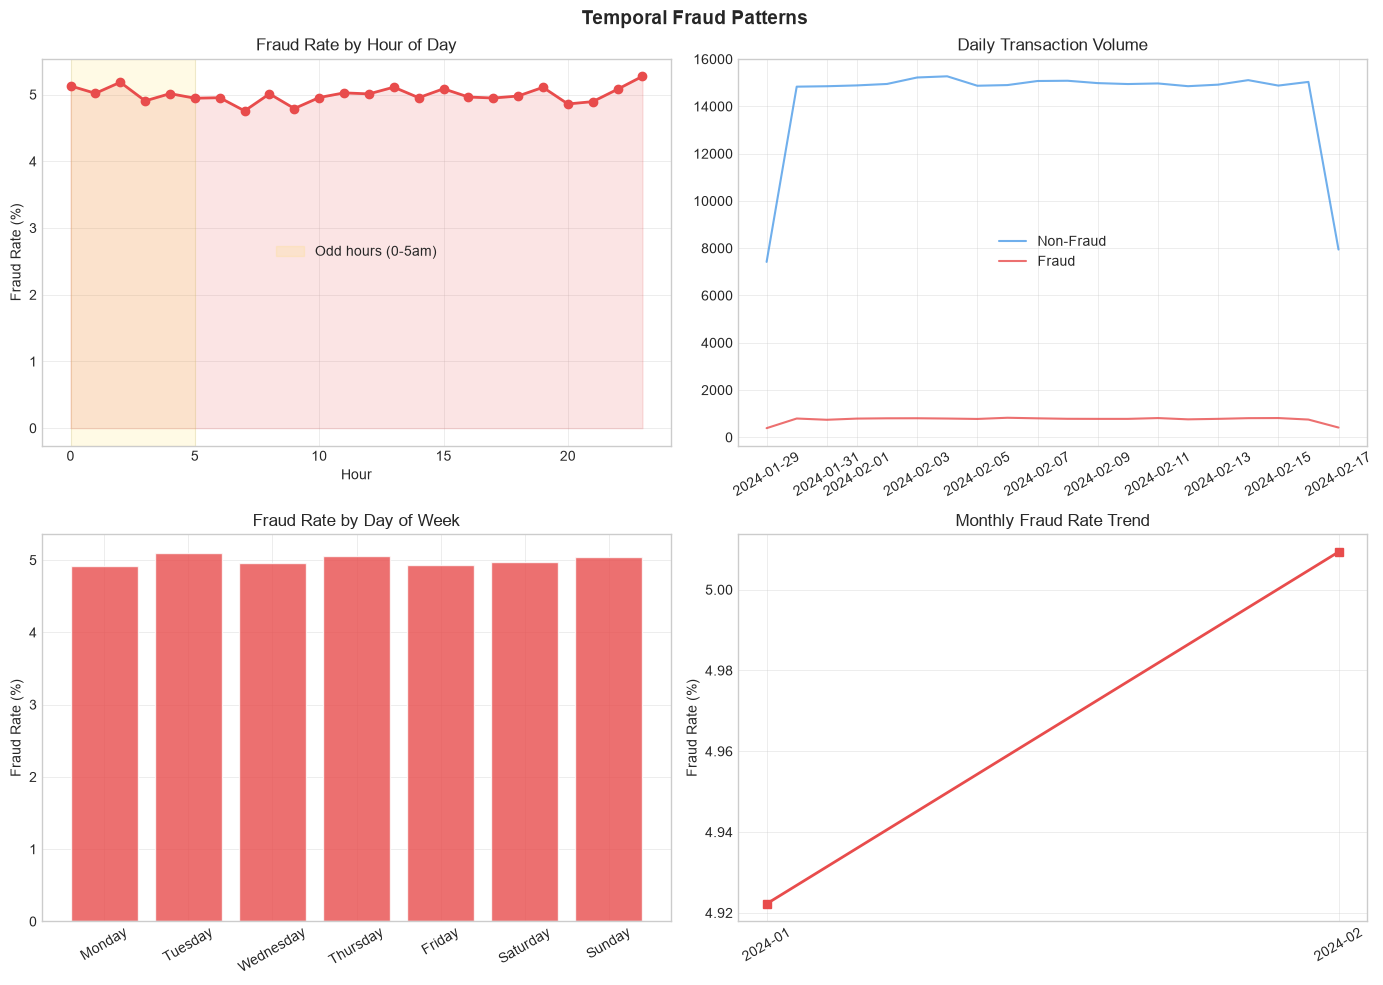


Peak fraud hour : 23:00  (5.27% fraud rate)
Peak fraud day  : Tuesday  (5.10% fraud rate)


In [8]:
# Temporal Patterns
df_t = (
    df.withColumn("hour",
                  when(col(DATE_COL).isNotNull(), hour(col(DATE_COL)))
                  .otherwise(col("Transaction Hour")))
      .withColumn("day_of_week", date_format(col(DATE_COL), "EEEE"))
      .withColumn("date", to_date(col(DATE_COL)))
      .withColumn("month", date_format(col(DATE_COL), "yyyy-MM"))
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Temporal Fraud Patterns", fontsize=14, fontweight="bold")

# Fraud rate by hour
hourly = (
    df_t.groupBy("hour")
        .agg(
            spark_sum(col(TARGET_COL)).alias("Fraud Count"),
            count("*").alias("Total")
        )
        .withColumn("fraud_rate", col("Fraud Count") / col("Total") * 100)
        .orderBy("hour")
        .toPandas()
)

axes[0,0].plot(hourly["hour"], hourly["fraud_rate"], marker="o",
               color="#E84C4C", linewidth=2)
axes[0,0].fill_between(hourly["hour"], hourly["fraud_rate"], alpha=0.15, color="#E84C4C")
axes[0,0].axvspan(0, 5, alpha=0.1, color="gold", label="Odd hours (0-5am)")
axes[0,0].set_title("Fraud Rate by Hour of Day")
axes[0,0].set_xlabel("Hour")
axes[0,0].set_ylabel("Fraud Rate (%)")
axes[0,0].legend()

# Daily volume
daily_pdf = (
    df_t.groupBy("date", TARGET_COL)
        .count()
        .orderBy("date", TARGET_COL)
        .toPandas()
)

daily = (
    daily_pdf.pivot_table(index="date", columns=TARGET_COL, values="count", fill_value=0)
             .sort_index()
)

for label, color in PALETTE.items():
    if label in daily.columns:
        axes[0,1].plot(daily.index, daily[label],
                       label="Fraud" if label else "Non-Fraud",
                       color=color, alpha=0.8)
axes[0,1].set_title("Daily Transaction Volume")
axes[0,1].legend()
axes[0,1].tick_params(axis="x", rotation=30)

# Fraud rate by day of week
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_fraud = (
    df_t.groupBy("day_of_week")
        .agg(
            spark_sum(col(TARGET_COL)).alias("Fraud Count"),
            count("*").alias("Total")
        )
        .withColumn("fraud_rate", col("Fraud Count") / col("Total") * 100)
        .toPandas()
)

dow_fraud["day_of_week"] = pd.Categorical(dow_fraud["day_of_week"], categories=dow_order, ordered=True)
dow_fraud = dow_fraud.dropna(subset=["day_of_week"]).sort_values("day_of_week")

axes[1,0].bar(dow_fraud["day_of_week"].astype(str), dow_fraud["fraud_rate"],
              color="#E84C4C", alpha=0.8, edgecolor="white")
axes[1,0].set_title("Fraud Rate by Day of Week")
axes[1,0].set_ylabel("Fraud Rate (%)")
axes[1,0].tick_params(axis="x", rotation=30)

# Monthly trend
monthly = (
    df_t.groupBy("month")
        .agg(
            spark_sum(col(TARGET_COL)).alias("Fraud Count"),
            count("*").alias("Total")
        )
        .withColumn("fraud_rate", col("Fraud Count") / col("Total") * 100)
        .orderBy("month")
        .toPandas()
)

axes[1,1].plot(range(len(monthly)), monthly["fraud_rate"],
               marker="s", color="#E84C4C", linewidth=2)
axes[1,1].set_xticks(range(len(monthly)))
axes[1,1].set_xticklabels(monthly["month"], rotation=30)
axes[1,1].set_title("Monthly Fraud Rate Trend")
axes[1,1].set_ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

# Insights
if not hourly.empty:
    peak_hour_row = hourly.loc[hourly["fraud_rate"].idxmax()]
    print(f"\nPeak fraud hour : {int(peak_hour_row['hour'])}:00  "
          f"({peak_hour_row['fraud_rate']:.2f}% fraud rate)")

if not dow_fraud.empty:
    peak_day_row = dow_fraud.loc[dow_fraud["fraud_rate"].idxmax()]
    print(f"Peak fraud day  : {peak_day_row['day_of_week']}  "
          f"({peak_day_row['fraud_rate']:.2f}% fraud rate)")


In [9]:
# Address Mismatch Signal
df_addr = df.withColumn(
    "address_mismatch",
    when(trim(col("Shipping Address")) != trim(col("Billing Address")), 1).otherwise(0)
)

mismatch_n = df_addr.filter(col("address_mismatch") == 1).count()
print(f"Address mismatch: {mismatch_n:,} ({mismatch_n/total_rows*100:.2f}% of all transactions)")

fraud_by_mismatch = (
    df_addr.groupBy("address_mismatch")
           .agg(
               spark_sum(col(TARGET_COL)).alias("Fraud Count"),
               count("*").alias("Total")
           )
           .withColumn("Fraud Rate (%)", col("Fraud Count") / col("Total") * 100)
           .orderBy("address_mismatch")
           .toPandas()
)

fraud_by_mismatch["address_mismatch"] = fraud_by_mismatch["address_mismatch"].map({
    0: "Address MATCH",
    1: "Address MISMATCH"
})

fraud_by_mismatch = fraud_by_mismatch.set_index("address_mismatch")
display(fraud_by_mismatch)

match_rate = fraud_by_mismatch.loc["Address MATCH", "Fraud Rate (%)"] if "Address MATCH" in fraud_by_mismatch.index else np.nan
mismatch_rate = fraud_by_mismatch.loc["Address MISMATCH", "Fraud Rate (%)"] if "Address MISMATCH" in fraud_by_mismatch.index else 0

if pd.notna(match_rate) and match_rate > 0 and mismatch_rate > 0:
    lift = mismatch_rate / match_rate
    print(f"\n→ Lift: {lift:.2f}x  {'Strong feature!' if lift > 1.5 else 'Weak signal'}")
else:
    print("\n→ Lift: không tính được do thiếu nhóm hoặc match_rate = 0")


Address mismatch: 30,046 (10.02% of all transactions)


,Fraud Count,Total,Fraud Rate (%)
address_mismatch,,,
Address MATCH,13482,269954,4.994184
Address MISMATCH,1512,30046,5.032284



→ Lift: 1.01x  Weak signal
